# **AdEase Time Series Case Study:**

# **Problem Statement:**

Ad Ease is an ads and marketing based company helping businesses elicit maximum clicks @ minimum cost. AdEase is an ad infrastructure to help businesses promote themselves easily, effectively, and economically. The interplay of 3 AI modules - Design, Dispense, and Decipher, come together to make it this an end-to-end 3 step process digital advertising solution for all.

You are working in the Data Science team of Ad ease trying to understand the per page view report for different wikipedia pages for 550 days, and forecasting the number of views so that you can predict and optimize the ad placement for your clients. You are provided with the data of 145k wikipedia pages and daily view count for each of them. Your clients belong to different regions and need data on how their ads will perform on pages in different languages.

# **Dataset Data dictionary:**

There are two csv files given.

- **train_1.csv:** In the csv file, each row corresponds to a particular article and each column corresponds to a particular date. The values are the number of visits on that date. The page name contains data in this format given below having information about the page name, the main domain, the device type used to access the page, and also the request origin(spider or browser agent).

SPECIFIC NAME _ LANGUAGE.wikipedia.org _ ACCESS TYPE _ ACCESS ORIGIN

- **Exog_Campaign_eng:** This file contains data for the dates which had a campaign or significant event that could affect the views for that day. The data is just for pages in English. There’s 1 for dates with campaigns and 0 for remaining dates. It is to be treated as an exogenous variable for models when training and forecasting data for pages in English

# **Concepts Used:**

- Exploratory data analysis
- Time Series forecasting -> ARIMA, SARIMAX, and Prophet

Dataset:
https://drive.google.com/drive/folders/1mdgQscjqnCtdg7LGItomyK0abN6lcHBb

# **Part A: Data Understanding & Initial Exploration**

In [1]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

In [2]:
# Check the characteristics and structure of the dataset
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/Case study/Ad_ease_data/train_1.csv")
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


### **Note: The frequency of data is daily**

In [3]:
# Print the last 5 rows
df.tail()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
145058,Underworld_(serie_de_películas)_es.wikipedia.o...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,13.0,12.0,13.0,3.0,5.0,10.0
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-acc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145061,Hasta_el_último_hombre_es.wikipedia.org_all-ac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145062,Francisco_el_matemático_(serie_de_televisión_d...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Print the shape of the dataframe
df.shape

(145063, 551)

In [5]:
# Column names
print(df.columns.tolist())

['Page', '2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08', '2015-07-09', '2015-07-10', '2015-07-11', '2015-07-12', '2015-07-13', '2015-07-14', '2015-07-15', '2015-07-16', '2015-07-17', '2015-07-18', '2015-07-19', '2015-07-20', '2015-07-21', '2015-07-22', '2015-07-23', '2015-07-24', '2015-07-25', '2015-07-26', '2015-07-27', '2015-07-28', '2015-07-29', '2015-07-30', '2015-07-31', '2015-08-01', '2015-08-02', '2015-08-03', '2015-08-04', '2015-08-05', '2015-08-06', '2015-08-07', '2015-08-08', '2015-08-09', '2015-08-10', '2015-08-11', '2015-08-12', '2015-08-13', '2015-08-14', '2015-08-15', '2015-08-16', '2015-08-17', '2015-08-18', '2015-08-19', '2015-08-20', '2015-08-21', '2015-08-22', '2015-08-23', '2015-08-24', '2015-08-25', '2015-08-26', '2015-08-27', '2015-08-28', '2015-08-29', '2015-08-30', '2015-08-31', '2015-09-01', '2015-09-02', '2015-09-03', '2015-09-04', '2015-09-05', '2015-09-06', '2015-09-07', '2015-09-08', '2015-09-09

In [6]:
# Info on the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 609.8+ MB


In [7]:
# Check missing values
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
Page,0,0.000000
2015-07-01,20740,14.297236
2015-07-02,20816,14.349627
2015-07-03,20544,14.162123
2015-07-04,20654,14.237952
...,...,...
2016-12-27,3701,2.551305
2016-12-28,3822,2.634717
2016-12-29,3826,2.637475
2016-12-30,3635,2.505808


In [8]:
# Missing values per row
missing_values_per_row = df.isnull().sum(axis = 1)
missing_values_per_row

,0
0,0
1,0
2,0
3,0
4,291
...,...
145058,544
145059,550
145060,550
145061,550


In [9]:
missing_values_per_row.describe()

,0
count,145063.000000
mean,42.691320
std,115.804572
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,550.000000


# **The dataset shows a higher percentage of missing values in earlier dates (around 14%) which gradually decreases to (around 2.3%) in later dates. This suggests that many pages were created after the dataset start date, leading to unavailable historical data. Hence, missing values are not random but indicate late page creation.**

In [10]:
# Understanding the page feature
df['Page'].head(20)

,Page
0,2NE1_zh.wikipedia.org_all-access_spider
1,2PM_zh.wikipedia.org_all-access_spider
2,3C_zh.wikipedia.org_all-access_spider
3,4minute_zh.wikipedia.org_all-access_spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...
5,5566_zh.wikipedia.org_all-access_spider
6,91Days_zh.wikipedia.org_all-access_spider
7,A'N'D_zh.wikipedia.org_all-access_spider
8,AKB48_zh.wikipedia.org_all-access_spider
9,ASCII_zh.wikipedia.org_all-access_spider


In [11]:
df['Page'].sample(10)

,Page
146,THE_K2_zh.wikipedia.org_all-access_spider
9428,Jennifer_Lawrence_en.wikipedia.org_desktop_all...
18808,"Стюарт,_Кристен_ru.wikipedia.org_mobile-web_al..."
57016,大貫亜美_ja.wikipedia.org_mobile-web_all-agents
92639,Virreinato_de_Nueva_España_es.wikipedia.org_al...
82524,Commons:Wiki_Loves_Africa_2016/Participate/ar_...
6618,L'Incroyable_Famille_Kardashian_fr.wikipedia.o...
135055,ストロベリーナイト_(テレビドラマ)_ja.wikipedia.org_all-access...
19475,Ледибаг_и_Супер-кот_ru.wikipedia.org_mobile-we...
53720,Jeux_de_pouvoir_(film)_fr.wikipedia.org_mobile...


In [12]:
# Checking the date columns
date_cols = df.columns[1:]

print("Number of date columns:", len(date_cols))
print("First 5 dates:", date_cols[:5])
print("Last 5 dates:", date_cols[-5:])

Number of date columns: 550
First 5 dates: Index(['2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04', '2015-07-05'], dtype='object')
Last 5 dates: Index(['2016-12-27', '2016-12-28', '2016-12-29', '2016-12-30', '2016-12-31'], dtype='object')


In [13]:
# Statictical overview
df.iloc[:, 1:].describe()

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
count,1.243230e+05,1.242470e+05,1.245190e+05,1.244090e+05,1.244040e+05,1.245800e+05,1.243990e+05,1.247690e+05,1.248190e+05,1.247210e+05,...,1.412100e+05,1.414790e+05,1.418740e+05,1.413190e+05,1.411450e+05,1.413620e+05,1.412410e+05,1.412370e+05,1.414280e+05,1.415980e+05
mean,1.195857e+03,1.204004e+03,1.133676e+03,1.170437e+03,1.217769e+03,1.290273e+03,1.239137e+03,1.193092e+03,1.197992e+03,1.189651e+03,...,1.394096e+03,1.377482e+03,1.393099e+03,1.523740e+03,1.679607e+03,1.678302e+03,1.633966e+03,1.684308e+03,1.467943e+03,1.478282e+03
std,7.275352e+04,7.421515e+04,6.961022e+04,7.257351e+04,7.379612e+04,8.054448e+04,7.576288e+04,6.820002e+04,7.149717e+04,7.214536e+04,...,8.574880e+04,7.732794e+04,8.478533e+04,8.752210e+04,9.794534e+04,9.232482e+04,9.185831e+04,9.014266e+04,8.155481e+04,8.873567e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.300000e+01,1.300000e+01,1.200000e+01,1.300000e+01,1.400000e+01,1.100000e+01,1.300000e+01,1.300000e+01,1.400000e+01,1.400000e+01,...,2.200000e+01,2.200000e+01,2.000000e+01,2.100000e+01,2.200000e+01,2.300000e+01,2.400000e+01,2.300000e+01,2.300000e+01,2.100000e+01
50%,1.090000e+02,1.080000e+02,1.050000e+02,1.050000e+02,1.130000e+02,1.130000e+02,1.150000e+02,1.170000e+02,1.150000e+02,1.130000e+02,...,1.490000e+02,1.430000e+02,1.320000e+02,1.450000e+02,1.600000e+02,1.620000e+02,1.630000e+02,1.600000e+02,1.540000e+02,1.360000e+02
75%,5.240000e+02,5.190000e+02,5.040000e+02,4.870000e+02,5.400000e+02,5.550000e+02,5.510000e+02,5.540000e+02,5.490000e+02,5.450000e+02,...,6.070000e+02,5.980000e+02,5.690000e+02,6.280000e+02,6.590000e+02,6.680000e+02,6.540000e+02,6.490000e+02,6.350000e+02,5.610000e+02
max,2.038124e+07,2.075219e+07,1.957397e+07,2.043964e+07,2.077211e+07,2.254467e+07,2.121089e+07,1.910791e+07,1.999385e+07,2.020182e+07,...,2.420108e+07,2.253925e+07,2.505662e+07,2.586575e+07,2.834288e+07,2.691699e+07,2.702505e+07,2.607382e+07,2.436397e+07,2.614954e+07


In [14]:
# Check Sparsity
missing_percentage = (df.isnull().sum().sum()/(df.shape[0] * df.shape[1])) * 100
print("Sparsity of the dataset:", round(missing_percentage,2), "%")

Sparsity of the dataset: 7.75 %


In [15]:
# Determine the number of days in the dataset
num_days = len(df.columns[1:])
print("Number of days in the dataset:", num_days)

min_date = pd.to_datetime(df.columns[1]).date()
max_date = pd.to_datetime(df.columns[-1]).date()

print("Start date:", min_date)
print("End date:", max_date)
print("Duration:", (max_date - min_date).days + 1)

Number of days in the dataset: 550
Start date: 2015-07-01
End date: 2016-12-31
Duration: 550


### **This aligns with the count we got for our DATE column**

### **The dataset contains 550 daily observations ranging from 1 July 2015 to 31 December 2016.The continuous nature of dates indicates a well structured time series suitable for forecasting.**

### **The overall sparsity of the dataset is approximately 7.75% which indicates a moderate presence of missing values. While not excessively sparse, appropriate imputation techniques will be required before modeling.**

In [16]:
# Check the skewness of the data
df.iloc[:, 1:].skew().mean()

np.float64(231.4772564882875)

### **The dataset is heavily positively skewed (right-skewed).**

In [17]:
df.index

RangeIndex(start=0, stop=145063, step=1)

# **Part A Summary:**

### **The dataset consists of approximately 145,000 Wikipedia pages with 550 daily observations per page. The data is structured in a wide format with dates as columns. Missing values are more prominent in earlier time periods (around 14%) and reduce significantly in later periods (around 2.5%) indicating that many pages were created after the tracking period began.**

### **The dataset spans from 1 July 2015 to 31 December 2016 with consistent daily intervals. The overall sparsity is around 7.75% which is manageable but requires preprocessing before modelling.**

# **Part B: Feature Engineering**

In [18]:
# Check the page feature
df['Page'].head(20)

,Page
0,2NE1_zh.wikipedia.org_all-access_spider
1,2PM_zh.wikipedia.org_all-access_spider
2,3C_zh.wikipedia.org_all-access_spider
3,4minute_zh.wikipedia.org_all-access_spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...
5,5566_zh.wikipedia.org_all-access_spider
6,91Days_zh.wikipedia.org_all-access_spider
7,A'N'D_zh.wikipedia.org_all-access_spider
8,AKB48_zh.wikipedia.org_all-access_spider
9,ASCII_zh.wikipedia.org_all-access_spider


In [19]:
# Split the page column into required components
parts_of_page = df['Page'].str.split('_', expand = True)

df['title'] = parts_of_page[0]
df['language'] = parts_of_page[1]
df['access_type'] = parts_of_page[2]
df['access_origin'] = parts_of_page[3]

df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,title,language,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,2NE1,zh.wikipedia.org,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,2PM,zh.wikipedia.org,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,3C,zh.wikipedia.org,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,4minute,zh.wikipedia.org,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,11.0,27.0,13.0,36.0,10.0,52,Hz,I,Love


In [20]:
df['language'].head()

,language
0,zh.wikipedia.org
1,zh.wikipedia.org
2,zh.wikipedia.org
3,zh.wikipedia.org
4,Hz


### **Let's take zh.wikipedia.org as an example:**
- **zh.wikipedia.org = Chinese Wikipedia**

- **zh → ISO language code for Chinese.**

- **It contains: Articles written in Chinese language and Content relevant to Chinese-speaking users globally.**

- **Example:**
    
    **English page: en.wikipedia.org/wiki/AI**

    **Chinese equivalent: zh.wikipedia.org/wiki/人工智能**

- **AdEase dataset is multi-regional and multi-lingual. Each language = different user base = different behavior i.e., zh traffic ≠ en traffic ≠ ja traffic**

### **Business Perspective:**
**1. Market Segmentation**

**2. Targeted Advertising**

**3. Regional Demand Forecasting**

**4. Campaign Effectiveness**

**5. Revenue Optimization**

**6. Content Strategy**

**The domain zh.wikipedia.org represents the Chinese Wikipedia, catering to Chinese-speaking users. Each language in the dataset reflects a distinct audience with unique behavior and preferences. Analyzing these differences helps businesses perform targeted advertising, optimize campaigns, and allocate budgets effectively. This enables better regional strategies and maximizes revenue through localized marketing decisions.**

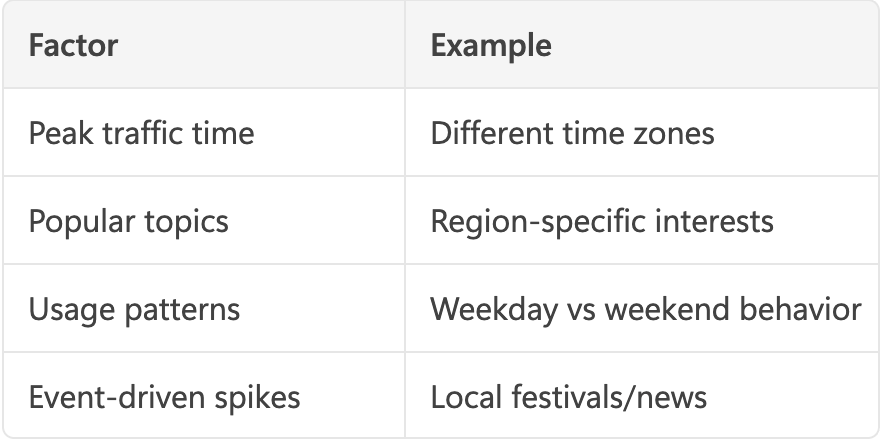

In [21]:
# Split the page column into required components
parts_of_page = df['Page'].str.rsplit('_', n = 3, expand = True)

df['title'] = parts_of_page[0]
df['language'] = parts_of_page[1]
df['access_type'] = parts_of_page[2]
df['access_origin'] = parts_of_page[3]

df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,title,language,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,2NE1,zh.wikipedia.org,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,2PM,zh.wikipedia.org,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,3C,zh.wikipedia.org,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,4minute,zh.wikipedia.org,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,11.0,27.0,13.0,36.0,10.0,52_Hz_I_Love_You,zh.wikipedia.org,all-access,spider


In [22]:
df['language'].head()

,language
0,zh.wikipedia.org
1,zh.wikipedia.org
2,zh.wikipedia.org
3,zh.wikipedia.org
4,zh.wikipedia.org


In [23]:
df['language'].value_counts()

,count
language,
en.wikipedia.org,24108
ja.wikipedia.org,20431
de.wikipedia.org,18547
fr.wikipedia.org,17802
zh.wikipedia.org,17229
ru.wikipedia.org,15022
es.wikipedia.org,14069
commons.wikimedia.org,10555
www.mediawiki.org,7300


In [24]:
# Extract language
df['language'] = df['language'].str.split('.').str[0]
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,title,language,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,2NE1,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,2PM,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,3C,zh,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,4minute,zh,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,11.0,27.0,13.0,36.0,10.0,52_Hz_I_Love_You,zh,all-access,spider


In [25]:
df['language'].value_counts()

,count
language,
en,24108
ja,20431
de,18547
fr,17802
zh,17229
ru,15022
es,14069
commons,10555
www,7300


In [26]:
# Validate
df[['Page', 'title', 'language', 'access_type', 'access_origin']].head()

,Page,title,language,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,2NE1,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,2PM,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,3C,zh,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,4minute,zh,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,52_Hz_I_Love_You,zh,all-access,spider


### **The 'Page' column contains multiple pieces of information embedded in a single string. It was split into 4 components - title, language, access type and access origin.**

### **The language was extracted from the domain name, enabling analysis across different regions. This transformation allows grouping and comparison of traffic patterns across languages, which is essential for regional ad optimization.**

### **Extracting language information enables segmentation of traffic patterns, allowing businesses to optimize ad placements based on regional audience behavior.**

### **The language component was extracted from the domain (ex: zh.wikipedia.org -> zh) to enable meaningful segmentation of traffic by region. The remaining part of the domain (wikipedia.org) was not used as it is constant across all observations and does not provide additional analytical value.**

In [27]:
# Check unique values in title, language, access type and access origin

print("Unique values in 'title':", df['title'].nunique())
print("Unique values in 'language':", df['language'].nunique())
print("Unique values in 'access_type':", df['access_type'].nunique())
print("Unique values in 'access_origin':", df['access_origin'].nunique())

Unique values in 'title': 49174
Unique values in 'language': 9
Unique values in 'access_type': 3
Unique values in 'access_origin': 2


In [28]:
df['language'].unique()

array(['zh', 'fr', 'en', 'commons', 'ru', 'www', 'de', 'ja', 'es'],
      dtype=object)

In [29]:
df['access_type'].unique()

array(['all-access', 'desktop', 'mobile-web'], dtype=object)

In [30]:
df['access_origin'].unique()

array(['spider', 'all-agents'], dtype=object)

### **The dataset includes entries labeled as 'commons' and 'www' which do not represent specific languages.**

### **'Commons' corresponds to Wikipedia Commons, a global repository for media files while 'www' represents generic wikipedia pages not tied to a specific language. These categories were treated separately during analysis as they do nor reflect original user behavior.**

# **Part C: Data Cleaning and Preparation**

In [31]:
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,title,language,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,2NE1,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,2PM,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,3C,zh,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,4minute,zh,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,11.0,27.0,13.0,36.0,10.0,52_Hz_I_Love_You,zh,all-access,spider


In [32]:
# Convert date columns to proper format
# Identify date columns
date_cols = df.columns[df.columns.to_series().astype(str).str.match(r'\d{4}-\d{2}-\d{2}')]

# Convert to Datetime
df.rename(columns = lambda x: pd.to_datetime(x) if str(x) in date_cols.astype(str).values else x, inplace = True)

In [33]:
# Verify
type(df.columns[1])

pandas._libs.tslibs.timestamps.Timestamp

In [34]:
# Re-identify date columns
date_cols = df.columns[df.columns.to_series().apply(lambda x: isinstance(x, pd.Timestamp))]

In [35]:
# Handle missing values

print("Before:", df[date_cols].isnull().sum().sum())
# Forward fill missing values
df[date_cols] = df[date_cols].ffill(axis = 1).fillna(0)
print("After:", df[date_cols].isnull().sum().sum())

Before: 6192931
After: 0


In [36]:
df.head()

,Page,2015-07-01 00:00:00,2015-07-02 00:00:00,2015-07-03 00:00:00,2015-07-04 00:00:00,2015-07-05 00:00:00,2015-07-06 00:00:00,2015-07-07 00:00:00,2015-07-08 00:00:00,2015-07-09 00:00:00,...,2016-12-26 00:00:00,2016-12-27 00:00:00,2016-12-28 00:00:00,2016-12-29 00:00:00,2016-12-30 00:00:00,2016-12-31 00:00:00,title,language,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,2NE1,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,2PM,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,3C,zh,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,4minute,zh,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,11.0,27.0,13.0,36.0,10.0,52_Hz_I_Love_You,zh,all-access,spider


In [37]:
df_sample = df.groupby('language', group_keys = False).apply(lambda x: x.sample(min(len(x),100)))

In [38]:
# Perform stratified sampling across languages for multiple sample sizes and validate the distribution

sample_sizes = [100,200,300]
samples_dict = {}
for size in sample_sizes:
  # Perform stratified sampling
  sample = df.groupby('language', group_keys = False).apply(lambda x: x.sample(min(len(x),size), random_state = 42))

  # Reset index
  sample.reset_index(drop = True, inplace = True)

  # Debugging/Validation
  print(f"\nSample size per language: {size}")
  print(f"Total rows: {sample.shape[0]}")
  print(f"\nLanguage distribution:")
  print(sample['language'].value_counts())
  print(f"Unique languages: {sample['language'].nunique()}")

  # Store the sample in the dictionary
  samples_dict[size] = sample


Sample size per language: 100
Total rows: 900

Language distribution:
language
commons    100
de         100
en         100
es         100
fr         100
ja         100
ru         100
www        100
zh         100
Name: count, dtype: int64
Unique languages: 9

Sample size per language: 200
Total rows: 1800

Language distribution:
language
commons    200
de         200
en         200
es         200
fr         200
ja         200
ru         200
www        200
zh         200
Name: count, dtype: int64
Unique languages: 9

Sample size per language: 300
Total rows: 2700

Language distribution:
language
commons    300
de         300
en         300
es         300
fr         300
ja         300
ru         300
www        300
zh         300
Name: count, dtype: int64
Unique languages: 9


In [39]:
# Sanity check
df_sample = samples_dict[200] # choose 200 samples
df_sample.shape

(1800, 555)

In [40]:
# Sanity check
df_sample.head()

,Page,2015-07-01 00:00:00,2015-07-02 00:00:00,2015-07-03 00:00:00,2015-07-04 00:00:00,2015-07-05 00:00:00,2015-07-06 00:00:00,2015-07-07 00:00:00,2015-07-08 00:00:00,2015-07-09 00:00:00,...,2016-12-26 00:00:00,2016-12-27 00:00:00,2016-12-28 00:00:00,2016-12-29 00:00:00,2016-12-30 00:00:00,2016-12-31 00:00:00,title,language,access_type,access_origin
0,User_talk:Jcb_commons.wikimedia.org_all-access...,2.0,1.0,3.0,8.0,2.0,1.0,1.0,1.0,0.0,...,30.0,53.0,51.0,92.0,135.0,73.0,User_talk:Jcb,commons,all-access,spider
1,Category:Dirty_Diaries_commons.wikimedia.org_m...,13.0,13.0,14.0,9.0,8.0,11.0,9.0,15.0,10.0,...,67.0,49.0,57.0,70.0,62.0,44.0,Category:Dirty_Diaries,commons,mobile-web,all-agents
2,"File:Oasis_de_Huacachina,_Ica,_Perú,_2015-07-2...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,6.0,7.0,11.0,6.0,25.0,"File:Oasis_de_Huacachina,_Ica,_Perú,_2015-07-2...",commons,desktop,all-agents
3,Category:Entertainment_commons.wikimedia.org_a...,15.0,28.0,11.0,15.0,10.0,8.0,21.0,34.0,19.0,...,41.0,26.0,24.0,25.0,26.0,22.0,Category:Entertainment,commons,all-access,spider
4,File:WLE_Austria_Logo_(transparent).svg_common...,2.0,3.0,1.0,0.0,9.0,1.0,2.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,File:WLE_Austria_Logo_(transparent).svg,commons,mobile-web,all-agents


In [41]:
# Sanity check
df_sample.isnull().sum().sum()

np.int64(0)

In [42]:
# Final validation
df_sample['language'].value_counts()

,count
language,
commons,200
de,200
en,200
es,200
fr,200
ja,200
ru,200
www,200
zh,200


# **Part D: EDA**

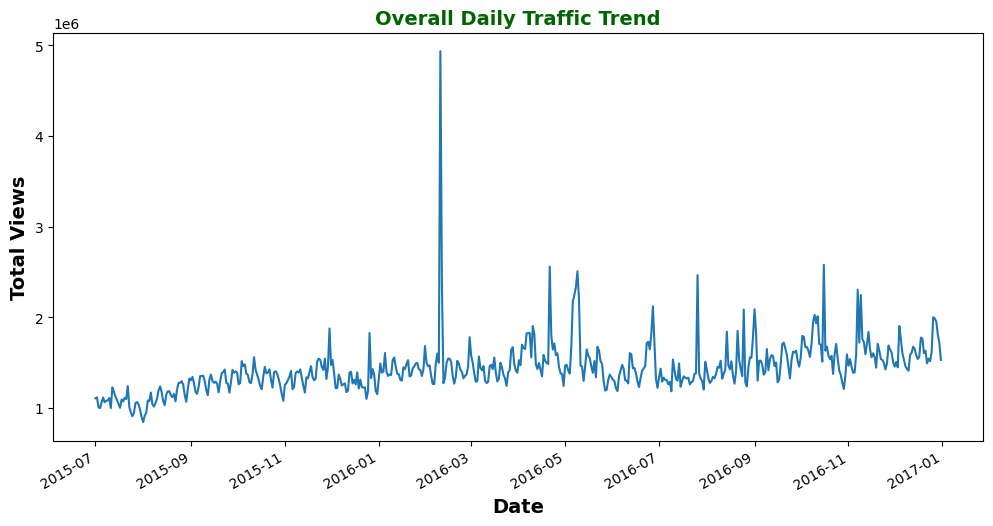

In [43]:
# Overall daily traffic trend to see overall usage pattern over time

# Identify date columns
date_cols = df_sample.columns[df_sample.columns.to_series().apply(lambda x: isinstance(x, pd.Timestamp))]

# Aggregate total views per day
daily_traffic = df_sample[date_cols].sum()

# Plot
plt.figure(figsize = (12,6))
daily_traffic.plot()
plt.title('Overall Daily Traffic Trend', fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel('Date', fontsize = 14, fontweight = 'bold')
plt.ylabel('Total Views', fontsize = 14, fontweight = 'bold')
plt.grid(False)
plt.show()

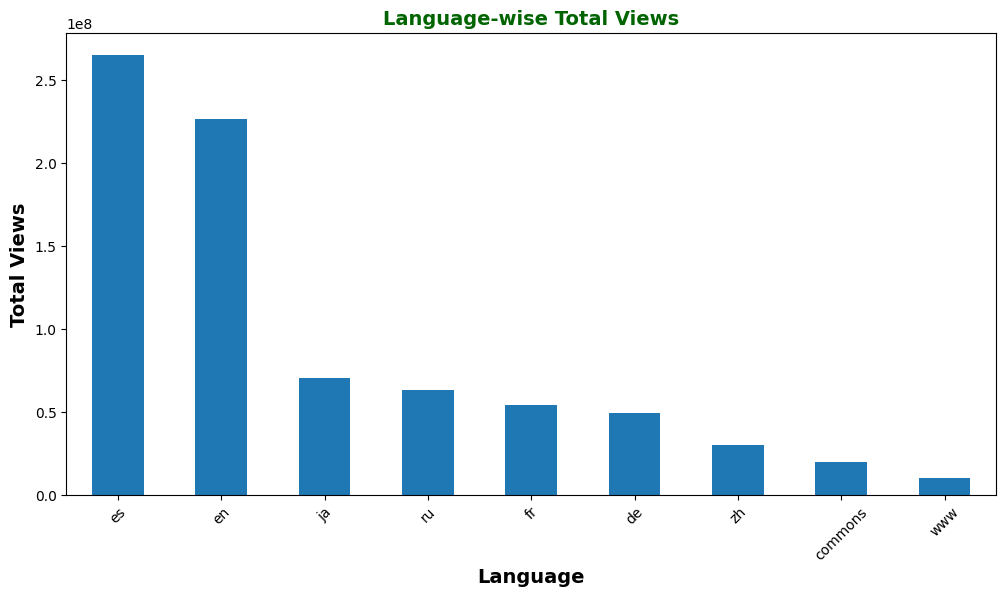

In [44]:
# Language wise total views to compare regions

language_views = df_sample.groupby('language')[date_cols].sum().sum(axis = 1)

# Plot
plt.figure(figsize = (12,6))
language_views.sort_values(ascending = False).plot(kind = 'bar')
plt.title('Language-wise Total Views', fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel('Language', fontsize = 14, fontweight = 'bold')
plt.ylabel('Total Views', fontsize = 14, fontweight = 'bold')
plt.xticks(rotation = 45)
plt.grid(False)
plt.show()

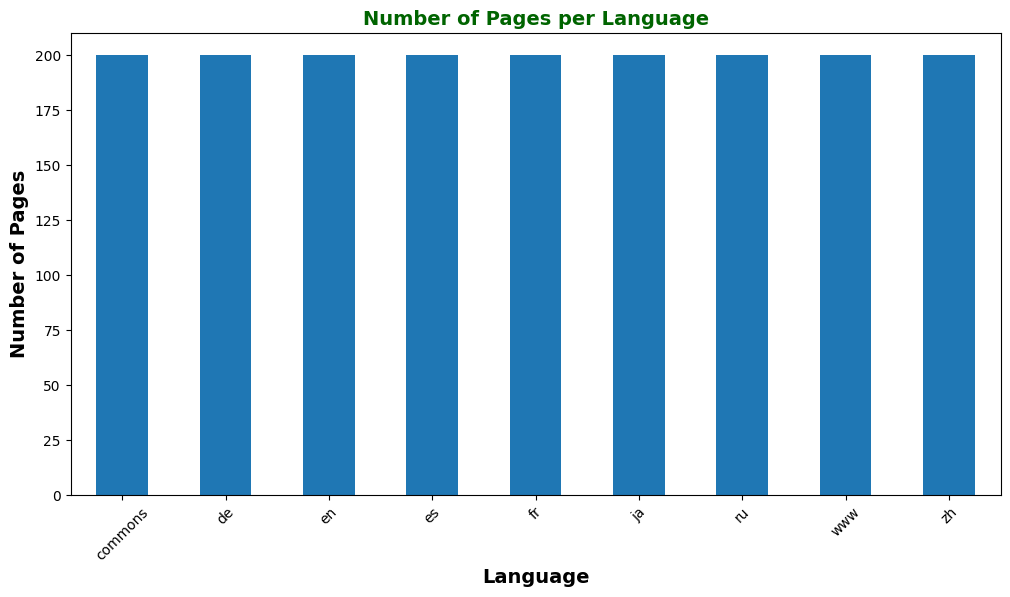

In [45]:
# Number of pages per language

plt.figure(figsize = (12,6))
df_sample['language'].value_counts().plot(kind = 'bar')
plt.title('Number of Pages per Language', fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel('Language', fontsize = 14, fontweight = 'bold')
plt.ylabel('Number of Pages', fontsize = 14, fontweight = 'bold')
plt.xticks(rotation = 45)
plt.grid(False)
plt.show()

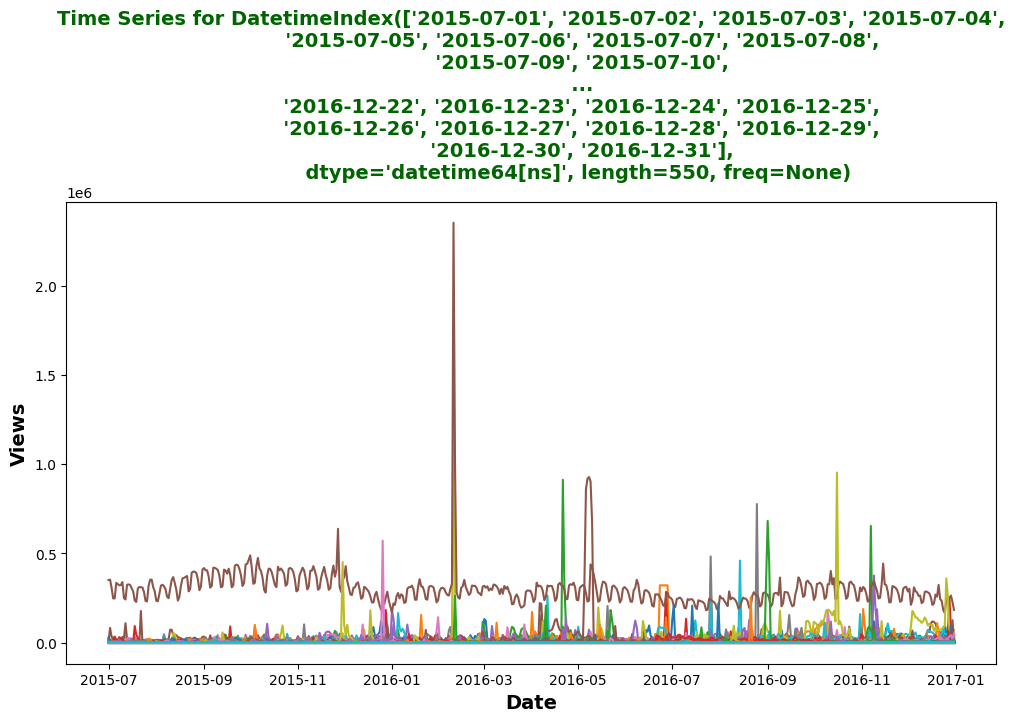

In [46]:
# Sample page time series to understand individual behavior

# Pick a series
series = df_sample[date_cols].T
series.index = pd.to_datetime(series.index)

# Plot
plt.figure(figsize = (12,6))
plt.plot(series)
plt.title(f'Time Series for {series.index}', fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel('Date', fontsize = 14, fontweight = 'bold')
plt.ylabel('Views', fontsize = 14, fontweight = 'bold')
plt.grid(False)
plt.show()

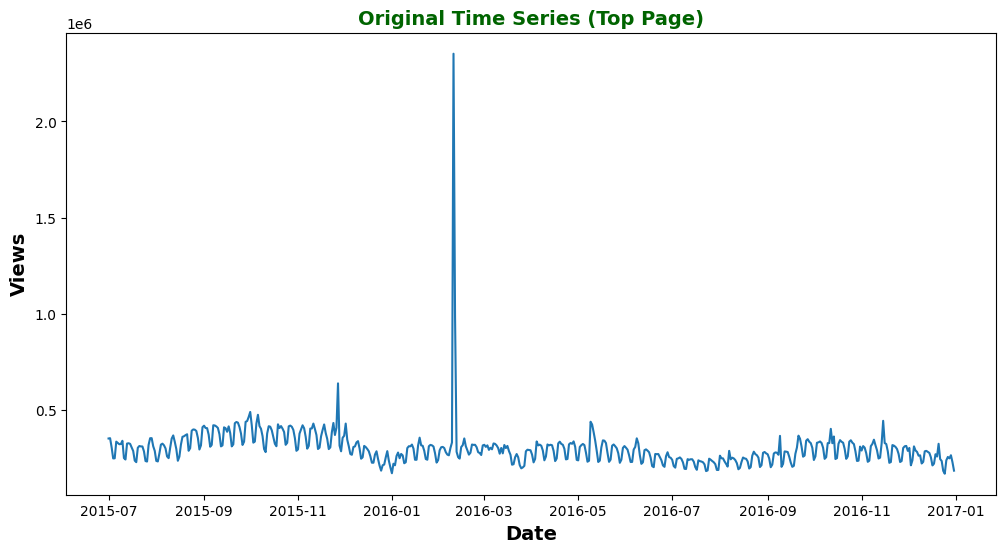

In [47]:
# Pick page with highest total views

# Identify date columns
date_cols = df_sample.columns[df_sample.columns.to_series().apply(lambda x: isinstance(x, pd.Timestamp))]

# Select page with highest traffic (stable series)
top_idx = df_sample[date_cols].sum(axis = 1).idxmax()
sample_page = df_sample.loc[top_idx]

# Extract time series
series = sample_page[date_cols].astype(float)
series.index = pd.to_datetime(series.index)

# Plot
plt.figure(figsize = (12,6))
plt.plot(series)
plt.title("Original Time Series (Top Page)", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Date", fontsize = 14, fontweight = 'bold')
plt.ylabel("Views", fontsize = 14, fontweight = 'bold')
plt.show()

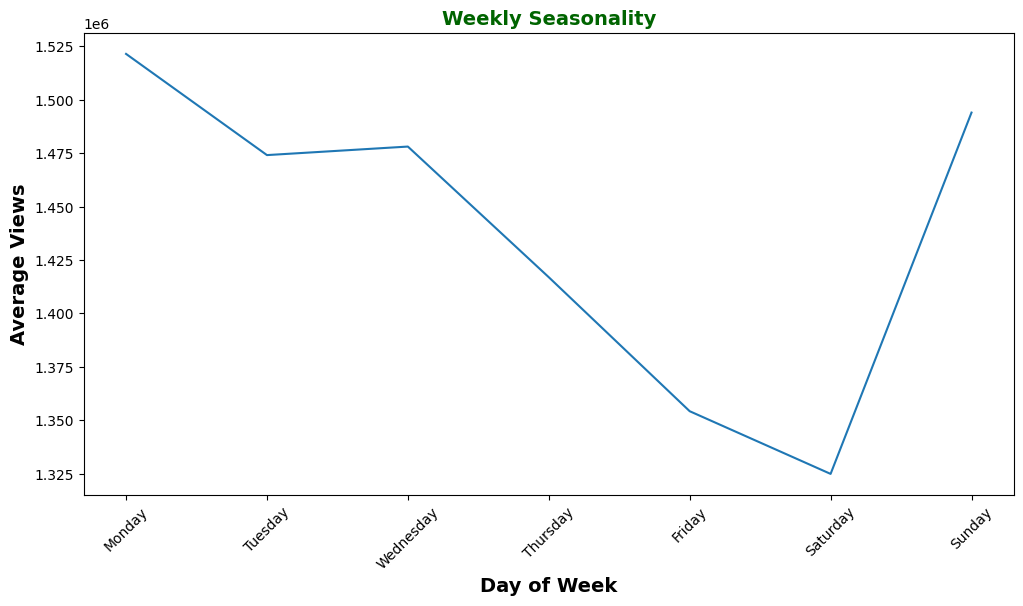

In [48]:
# Weekly seasonality to check if traffic depends on day of week

# Convert to Dataframe
daily_traffic_df = daily_traffic.reset_index()
daily_traffic_df.columns = ['Date', 'Views']

daily_traffic_df['Date'] = pd.to_datetime(daily_traffic_df['Date'])
daily_traffic_df['DayName'] = daily_traffic_df['Date'].dt.day_name()

# Average by day
weekday_avg = daily_traffic_df.groupby('DayName')['Views'].mean()
weekday_avg = weekday_avg.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Plot
plt.figure(figsize = (12,6))
plt.plot(weekday_avg)
plt.title('Weekly Seasonality', fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel('Day of Week', fontsize = 14, fontweight = 'bold')
plt.ylabel('Average Views', fontsize = 14, fontweight = 'bold')
plt.xticks(rotation = 45)
plt.grid(False)
plt.show()

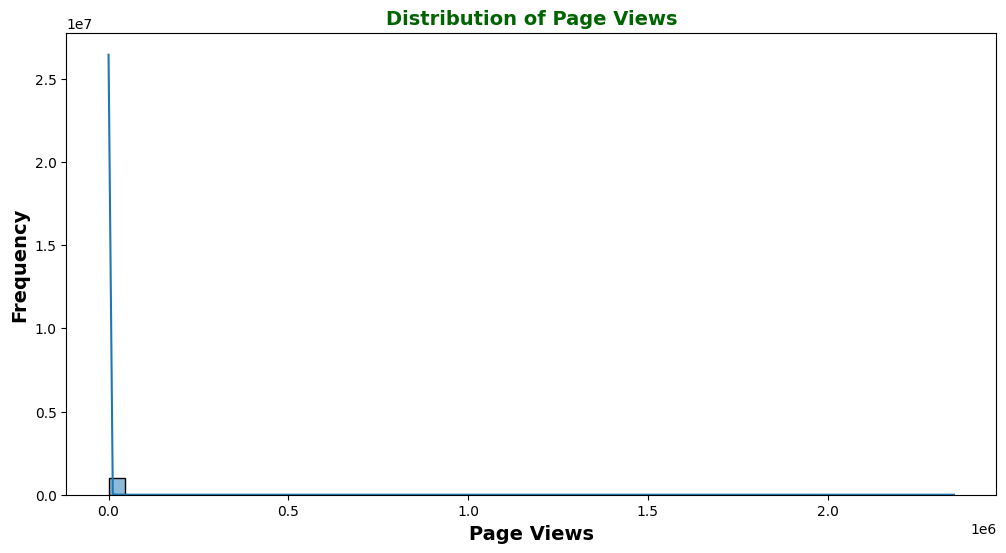

In [49]:
# Distribution of page views to check skewness

# Flatten values
values = df_sample[date_cols].values.flatten()

# Plot
plt.figure(figsize = (12,6))
sns.histplot(values, bins = 50, kde = True)
plt.title('Distribution of Page Views', fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel('Page Views', fontsize = 14, fontweight = 'bold')
plt.ylabel('Frequency', fontsize = 14, fontweight = 'bold')
plt.grid(False)
plt.show()

# **Part E: Stationarity + ACF/PACF + Time Series Forecasting**

# **Part E1: ARIMA on Raw Series**

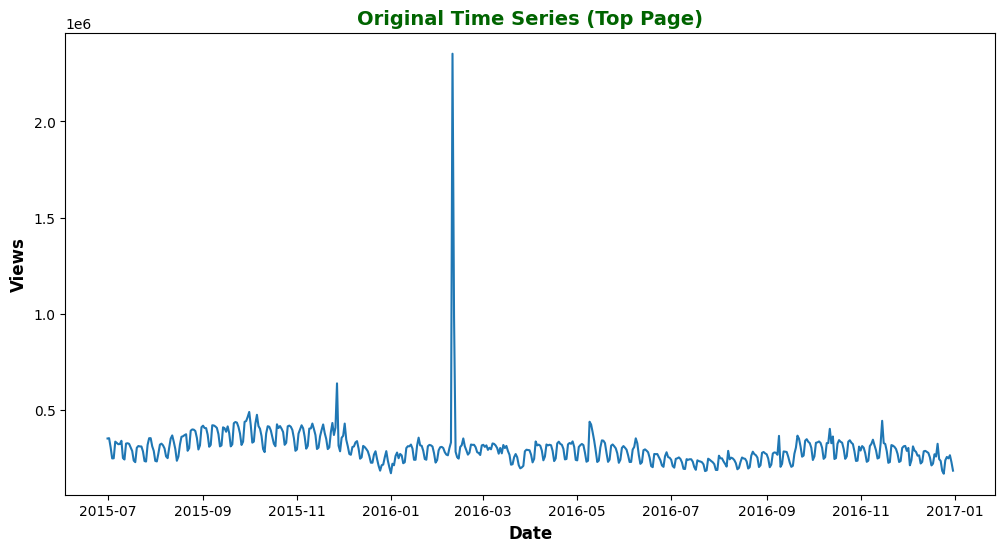

In [50]:
# Step 1: Pick page with highest total views

# Identify date columns
date_cols = df_sample.columns[df_sample.columns.to_series().apply(lambda x: isinstance(x, pd.Timestamp))]

# Select page with highest traffic (stable series)
top_idx = df_sample[date_cols].sum(axis = 1).idxmax()
sample_page = df_sample.loc[top_idx]

# Extract time series
series = sample_page[date_cols].astype(float)
series.index = pd.to_datetime(series.index)

# Plot
plt.figure(figsize = (12,6))
plt.plot(series)
plt.title("Original Time Series (Top Page)", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Date", fontsize = 12, fontweight = 'bold')
plt.ylabel("Views", fontsize = 12, fontweight = 'bold')
plt.show()

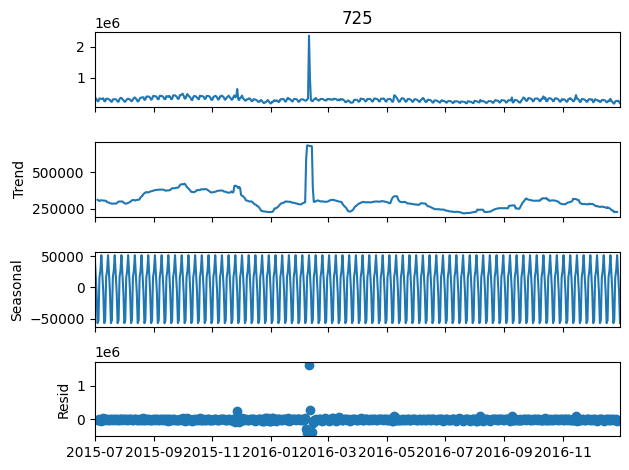

In [51]:
# Step 2: Time Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(series, model = 'additive', period = 7)
decomp.plot()
plt.show()

In [52]:
# Step 3: ADF Test (Stationarity Check)
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(series)
adf_statistic = adf_result[0]
p_value = adf_result[1]

print("ADF Statistic:", adf_statistic)
print("p-value:", p_value)

if p_value <= 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")

ADF Statistic: -5.217090483622168
p-value: 8.112531616954444e-06
The time series is stationary.


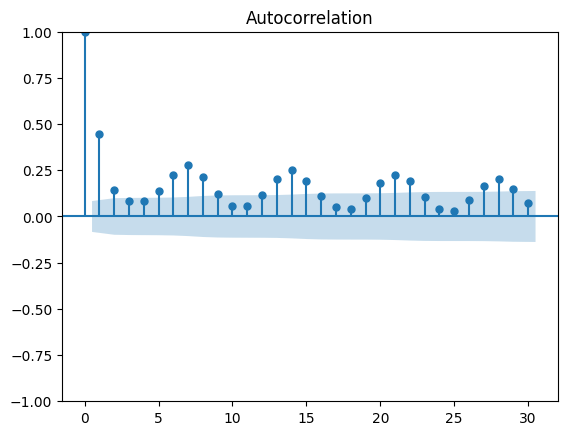

In [53]:
# Step 4: ACF Plot
# Used to identify q (MA order)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(series, lags = 30)
plt.show()

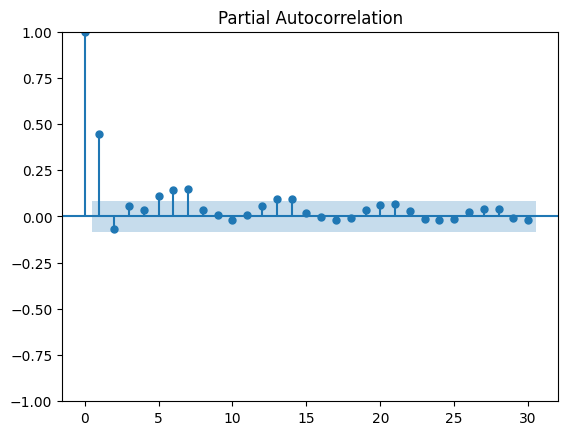

In [54]:
# Step 5: PACF Plot
# Used to identify p (AR order)
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(series, lags = 30)
plt.show()

In [55]:
# Step 6: Train-Test split (80-20)
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 440
Test size: 110


In [56]:
# Step 7: Baseline model with (p,d,q) = (1,0,1)
from statsmodels.tsa.arima.model import ARIMA

model_101 = ARIMA(train, order = (1,0,1))
result_101 = model_101.fit()

print("ARIMA(1,0,1) AIC:", result_101.aic)

ARIMA(1,0,1) AIC: 11463.998645099562


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [57]:
# Step 8: Forecast
forecast = result_101.forecast(steps = len(test))
forecast.index = test.index

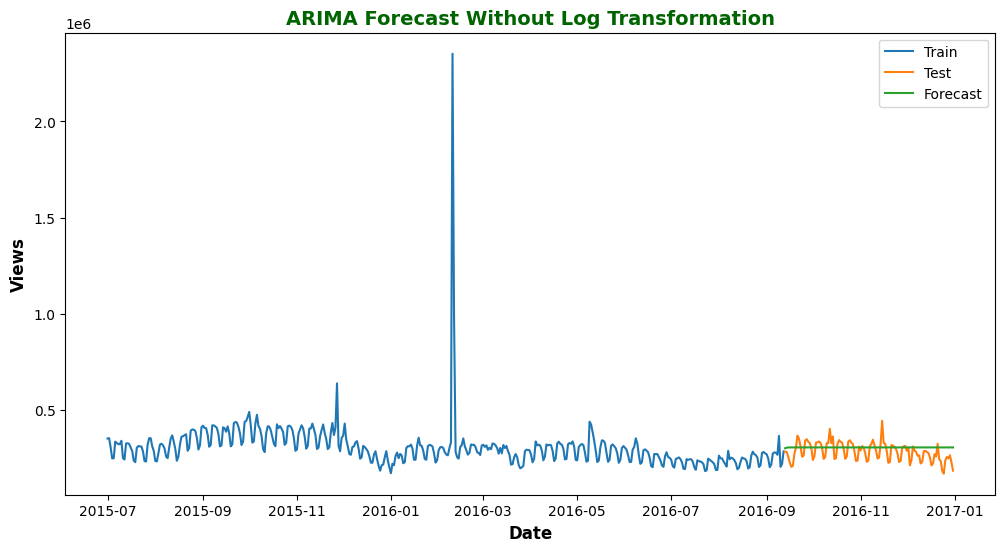

In [58]:
# Step 9: Plot
plt.figure(figsize = (12,6))
plt.plot(train, label = 'Train')
plt.plot(test, label = 'Test')
plt.plot(forecast, label = 'Forecast')
plt.legend()
plt.title("ARIMA Forecast Without Log Transformation", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel('Date', fontsize = 12, fontweight = 'bold')
plt.ylabel('Views', fontsize = 12, fontweight = 'bold')
plt.grid(False)
plt.show()

In [59]:
# Step 10: MAPE - Mean Absolute Percentage Error

def mape(y_true, y_pred):
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("ARIMA MAPE:", mape(test, forecast))

ARIMA MAPE: 16.51164240002824


# **📄 Insight: The time series for the high-traffic page exhibited relatively stable behavior and was found to be stationary without log transformation.**

# **Part E1: ARIMA on Log Transformed Series**

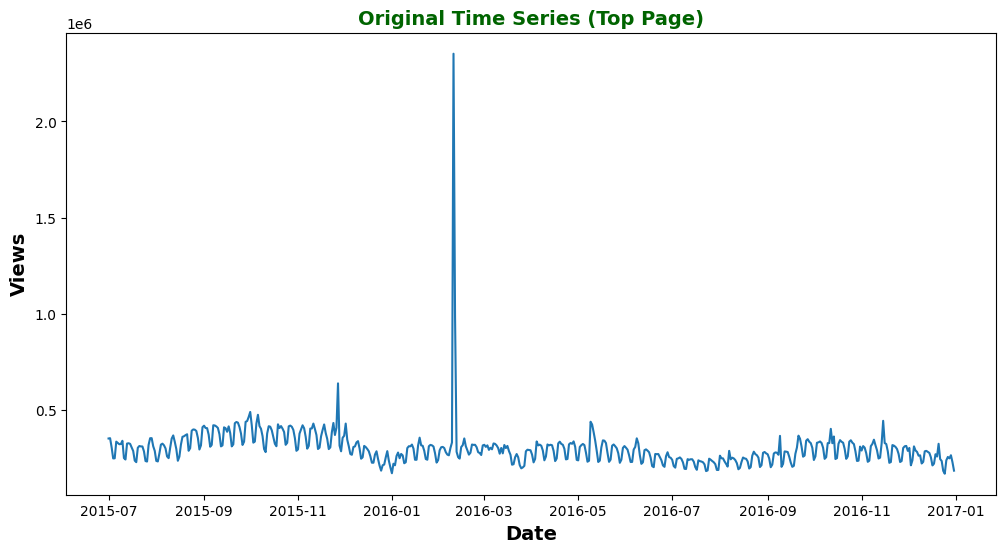

In [60]:
# Step 1: Pick page with highest total views

# Identify date columns
date_cols = df_sample.columns[df_sample.columns.to_series().apply(lambda x: isinstance(x, pd.Timestamp))]

# Select page with highest traffic (stable series)
top_idx = df_sample[date_cols].sum(axis = 1).idxmax()
sample_page = df_sample.loc[top_idx]

# Extract time series
series = sample_page[date_cols].astype(float)
series.index = pd.to_datetime(series.index)

# Plot original series
plt.figure(figsize = (12,6))
plt.plot(series)
plt.title("Original Time Series (Top Page)", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Date", fontsize = 14, fontweight = 'bold')
plt.ylabel("Views", fontsize = 14, fontweight = 'bold')
plt.show()

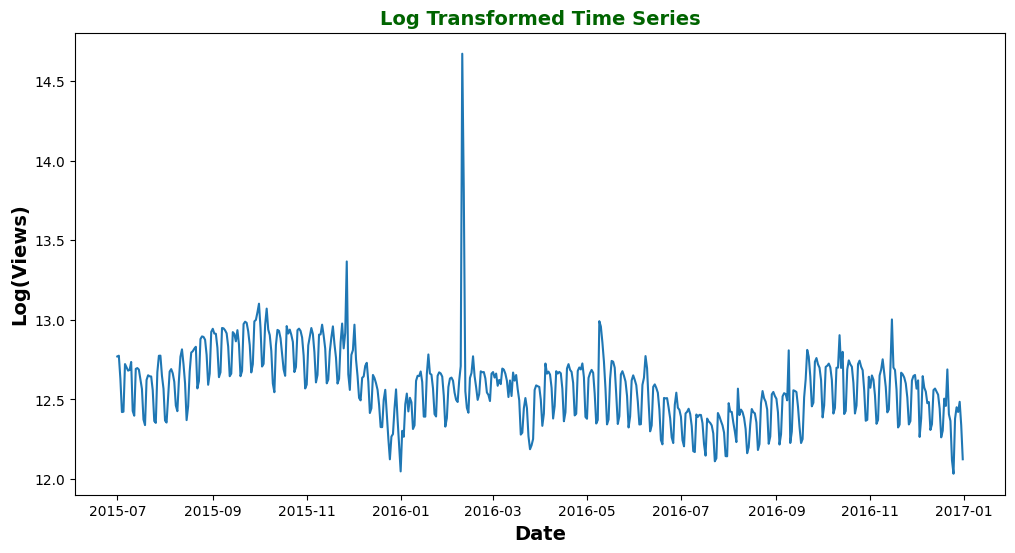

In [61]:
# Step 2: APPLY LOG TRANSFORMATION
# Apply log transform
series_log = np.log1p(series)

# Plot transformed data
plt.figure(figsize = (12,6))
plt.plot(series_log)
plt.title("Log Transformed Time Series", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Date", fontsize = 14, fontweight = 'bold')
plt.ylabel("Log(Views)", fontsize = 14, fontweight = 'bold')
plt.show()

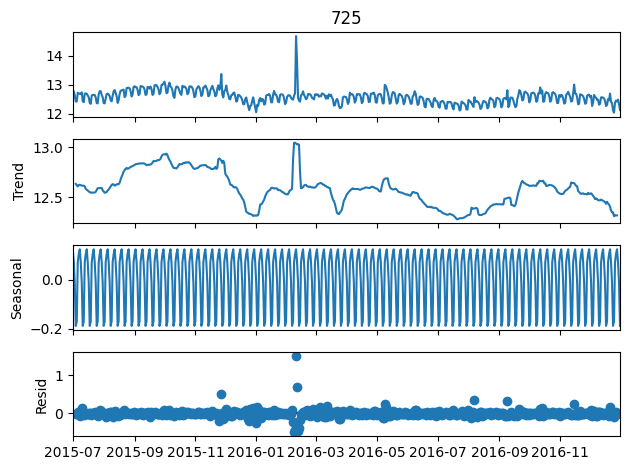

In [62]:
# Step 3: Time Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(series_log, model = 'additive', period = 7)
decomp.plot()
plt.show()

In [63]:
# Step 4: ADF Test (Stationarity Check)
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(series_log)
adf_statistic = adf_result[0]
p_value = adf_result[1]

print("ADF Statistic:", adf_statistic)
print("p-value:", p_value)

if p_value <= 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")

ADF Statistic: -1.955995458219144
p-value: 0.30619438844566543
The time series is not stationary.


In [64]:
# Step 5: Differencing
series_log_diff = series_log.diff().dropna()

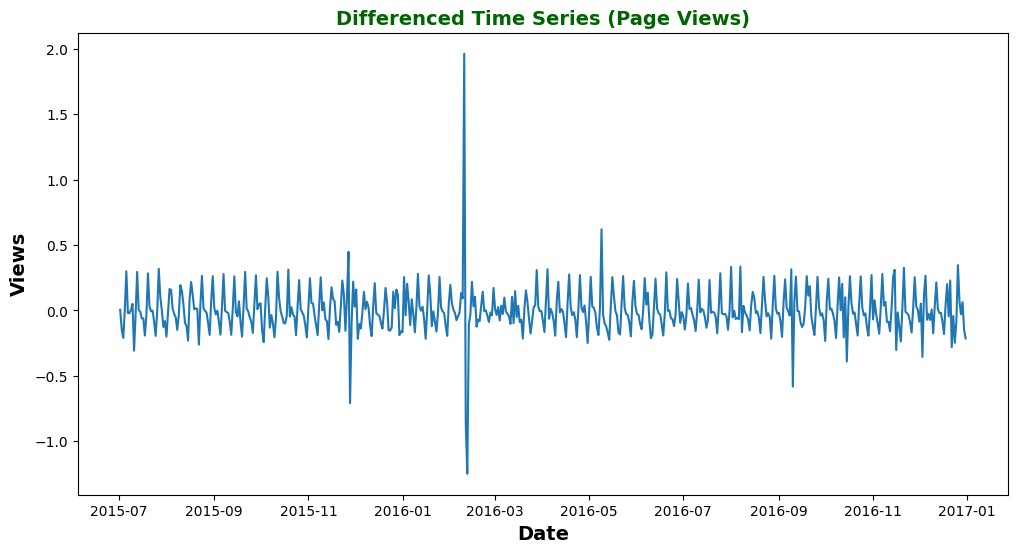

In [65]:
# Step 6: Plot differenced series

plt.figure(figsize = (12,6))
plt.plot(series_log_diff)
plt.title('Differenced Time Series (Page Views)', fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel('Date', fontsize = 14, fontweight = 'bold')
plt.ylabel('Views', fontsize = 14, fontweight = 'bold')
plt.grid(False)
plt.show()

In [66]:
# Step 7: ADF Test (Stationarity Check)
adf_result_diff = adfuller(series_log_diff)
print("ADF Statistic (after diff):", adf_result_diff[0])
print("p-value (after diff):", adf_result_diff[1])
adf_statistic_diff = adf_result_diff[0]
p_value_diff = adf_result_diff[1]

print("ADF Statistic:", adf_result_diff)
print("p-value:", p_value_diff)

if p_value_diff <= 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")

ADF Statistic (after diff): -7.655667776303819
p-value (after diff): 1.74176151186308e-11
ADF Statistic: (np.float64(-7.655667776303819), np.float64(1.74176151186308e-11), 19, 529, {'1%': np.float64(-3.442772146350605), '5%': np.float64(-2.8670191055991836), '10%': np.float64(-2.5696881663873414)}, np.float64(-645.5452225997738))
p-value: 1.74176151186308e-11
The time series is stationary.


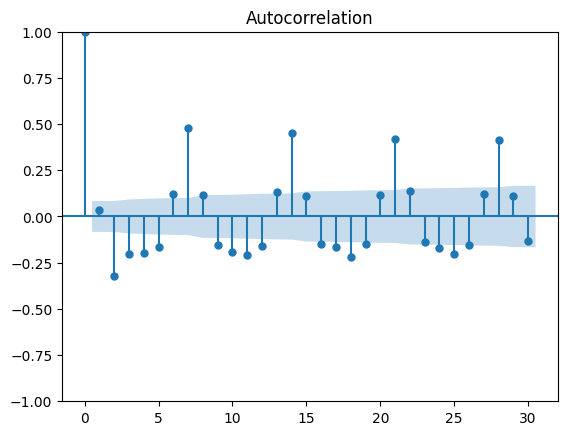

In [67]:
# Step 8: ACF Plot
# Used to identify q (MA order)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(series_log_diff, lags = 30)
plt.show()

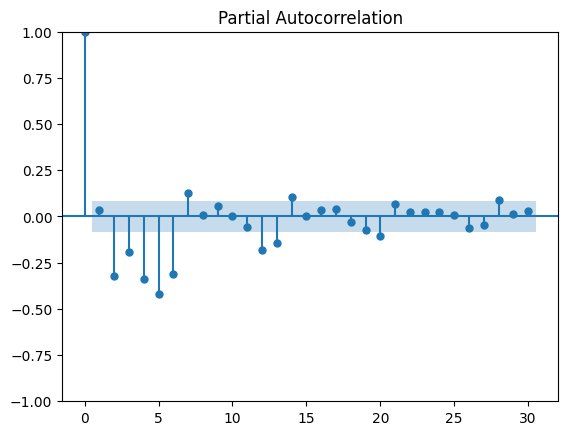

In [68]:
# Step 9: PACF Plot
# Used to identify p (AR order)
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(series_log_diff, lags = 30)
plt.show()

In [69]:
# Step 10: Train-Test split (80-20)
train_size = int(len(series_log) * 0.8)

train = series_log[:train_size]
test = series_log[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 440
Test size: 110


In [70]:
# Step 11: Baseline model with (p,d,q) = (1,1,1)
from statsmodels.tsa.arima.model import ARIMA

model_111 = ARIMA(train, order = (1,1,1))
result_111 = model_111.fit()

print("ARIMA(1,1,1) AIC:", result_111.aic)

ARIMA(1,1,1) AIC: -328.23146134207974


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [71]:
# Step 12: Hyperparameter Tuning with orders = (2,1,1) and (1,1,2)
orders = [(2,1,1), (1,1,2)]

results_dict = {}

for order in orders:
    model = ARIMA(train, order=order)
    result = model.fit()
    print(f"ARIMA{order} AIC:", result.aic)
    results_dict[order] = result

for order in orders:
    model = ARIMA(train, order=order)
    result = model.fit()
    print(f"ARIMA{order} AIC:", result.aic)
    results_dict[order] = result

# Select best model
best_order = min(results_dict, key=lambda x: results_dict[x].aic)
best_model = results_dict[best_order]

print("\nBest Model:", best_order)
print("Best AIC:", best_model.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

ARIMA(2, 1, 1) AIC: -397.23022992123833
ARIMA(1, 1, 2) AIC: -380.0856824172523


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

ARIMA(2, 1, 1) AIC: -397.23022992123833
ARIMA(1, 1, 2) AIC: -380.0856824172523

Best Model: (2, 1, 1)
Best AIC: -397.23022992123833


The ACF and PACF plots were analyzed on the log-transformed differenced series. The ACF plot showed significant autocorrelation at lag 1, while the PACF plot also indicated strong correlation at lag 1 and moderate influence at lag 2. Based on this, ARIMA(1,1,1) was selected as the baseline model.
To improve model performance, nearby parameter combinations such as ARIMA(2,1,1) and ARIMA(1,1,2) were evaluated. The ARIMA(2,1,1) model achieved the lowest AIC and was selected as the final model.

In [72]:
# Step 13: Forecast with best model
forecast = best_model.forecast(steps = len(test))
forecast.index = test.index

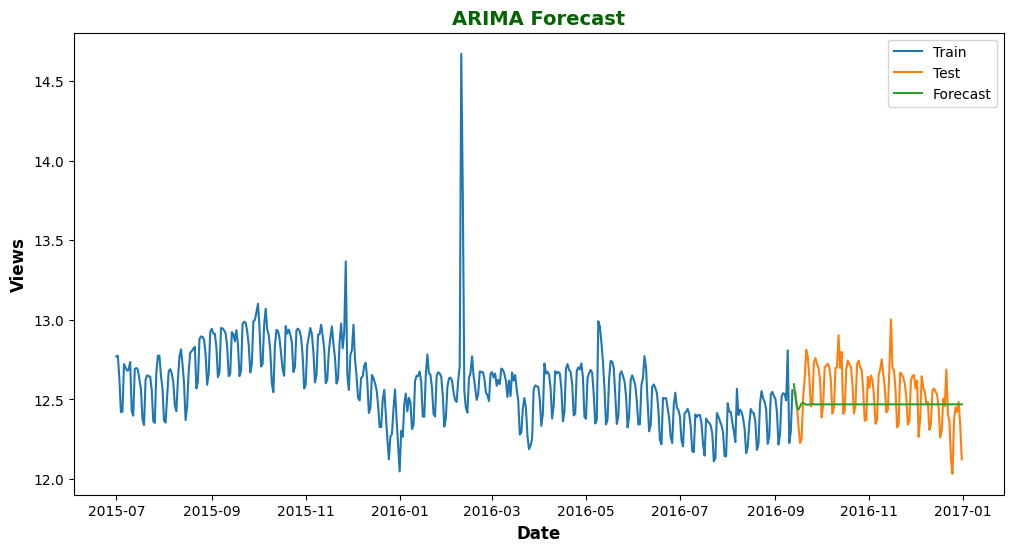

In [73]:
# Step 14: Plot
plt.figure(figsize = (12,6))
plt.plot(train, label = 'Train')
plt.plot(test, label = 'Test')
plt.plot(forecast, label = 'Forecast')
plt.legend()
plt.title("ARIMA Forecast", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel('Date', fontsize = 12, fontweight = 'bold')
plt.ylabel('Views', fontsize = 12, fontweight = 'bold')
plt.grid(False)
plt.show()

In [74]:
# Step 15: MAPE - Mean Absolute Percentage Error

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print("ARIMA MAPE:", mape(test, forecast))

ARIMA MAPE: 1.2256858635514232


### **ARIMA model was successfully applied on the raw series. However, the model performance improved further after applying log transformation. The transformation helped stabilize minor variations and enhanced model accuracy, resulting in a lower MAPE.**

# **📄 ARIMA Performance**

- **The ARIMA model was evaluated on both the raw and log-transformed time series for a high-traffic Wikipedia page.**
- **On the raw data, even though the series appeared stationary, the ARIMA(1,0,1) model resulted in a higher forecasting error (MAPE ≈ 16.51%) due to the presence of variability and irregular fluctuations.**
- **This indicates that the model struggled to capture fluctuations in the original scale of the data.**
- **After applying log transformation, the variance of the series was stabilized and underlying patterns became more structured. This allowed the ARIMA model to better capture the data dynamics.**
- **The final tuned ARIMA(2,1,1) model achieved a significantly lower MAPE of approximately 1.23%, indicating excellent predictive accuracy.**
- **This highlights the importance of variance stabilization in time series modeling and demonstrates how appropriate transformation can dramatically enhance forecasting accuracy.**
- **Even though the raw series appeared stationary, it still had variability that affected model performance. Log transformation reduced variance and made patterns more consistent, allowing ARIMA to capture the structure more effectively.**

# **Part E2: SARIMAX**

In [75]:
# Step 1: Load the Campaign Data file
exog = pd.read_csv("/content/drive/MyDrive/Datasets/Case study/Ad_ease_data/Exog_Campaign_eng")

In [76]:
# Step 2: Convert to series
exog_series = exog['Exog']

In [77]:
# Step 3: Match length with log series
print("Length of log_series:", len(series_log))
print("Length of exog_series:", len(exog_series))

Length of log_series: 550
Length of exog_series: 550


### **Exog Series length is also 550 rows as the logged series.**

In [78]:
# Step 4: Assign index. Align index with series
exog_series.index = series_log.index

In [79]:
exog_series.head()

,Exog
2015-07-01,0
2015-07-02,0
2015-07-03,0
2015-07-04,0
2015-07-05,0


In [80]:
# Step 5: Train/Test split for exog
train_log = series_log[:train_size]
test_log = series_log[train_size:]

exog_train = exog_series[:train_size]
exog_test = exog_series[train_size:]

In [84]:
# Step 6: Perform SARIMAX hyperparameter tuning over selected (order, seasonal_order) combinations and store results based on AIC

from statsmodels.tsa.statespace.sarimax import SARIMAX

param_grid = [
    ((1,1,1), (1,1,1,7)),
    ((2,1,1), (1,1,1,7)),
    ((1,1,2), (1,1,1,7)),
    ((2,1,2), (1,1,1,7)),
    ((2,1,1), (2,1,1,7))]

sarimax_results = {}

for order, seasonal in param_grid:
    try:
        model = SARIMAX(train_log, exog = exog_train, order = order, seasonal_order = seasonal)
        result = model.fit(maxiter = 200, method = 'lbfgs')
        print(f"SARIMAX{order}x{seasonal} AIC:", result.aic)
        sarimax_results[(order, seasonal)] = result
    except:
        continue

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMAX(1, 1, 1)x(1, 1, 1, 7) AIC: -515.5082089627599


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMAX(2, 1, 1)x(1, 1, 1, 7) AIC: -531.5230534137077


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMAX(1, 1, 2)x(1, 1, 1, 7) AIC: -537.613140886888


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMAX(2, 1, 2)x(1, 1, 1, 7) AIC: -535.7052579296441


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMAX(2, 1, 1)x(2, 1, 1, 7) AIC: -529.8845088449101


In [85]:
best_sarimax_key = min(sarimax_results, key = lambda x: sarimax_results[x].aic)
best_sarimax = sarimax_results[best_sarimax_key]

print("\nBest SARIMAX model:", best_sarimax_key)
print("Best AIC:", best_sarimax.aic)


Best SARIMAX model: ((1, 1, 2), (1, 1, 1, 7))
Best AIC: -537.613140886888


In [86]:
# Step 7: Forecast with best model
sarimax_forecast_log = best_sarimax.forecast(steps = len(test_log), exog = exog_test)
sarimax_forecast_log.index = test_log.index

In [87]:
# Step 8: Convert log-transformed forecasts and actual values back to original scale for interpretation and evaluation
sarimax_forecast = np.expm1(sarimax_forecast_log)
test_actual = np.expm1(test_log)
train_actual = np.expm1(train_log)

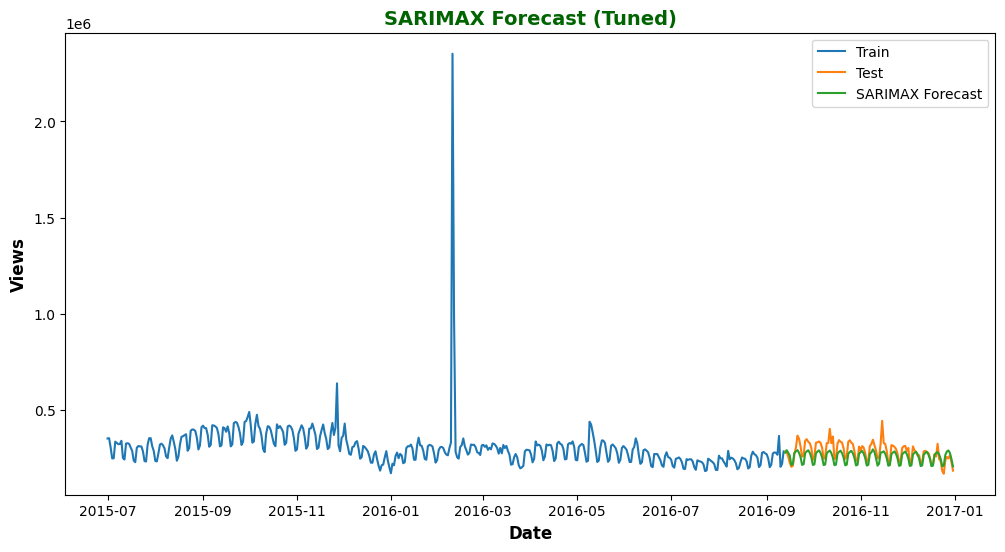

In [88]:
# Step 9: Plot
plt.figure(figsize = (12,6))
plt.plot(train_actual, label = 'Train')
plt.plot(test_actual, label = 'Test')
plt.plot(sarimax_forecast, label = 'SARIMAX Forecast')
plt.legend()
plt.title("SARIMAX Forecast (Tuned)", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel('Date', fontsize = 12, fontweight = 'bold')
plt.ylabel('Views', fontsize = 12, fontweight = 'bold')
plt.grid(False)
plt.show()

In [89]:
# Step 10: MAPE - Mean Absolute Percentage Error
print("SARIMAX MAPE:", mape(test_actual, sarimax_forecast))

SARIMAX MAPE: 11.722387409700245


# **📄 SARIMAX Performance**

- **The SARIMAX model was trained using log-transformed data along with campaign data as an exogenous variable.**
- **Hyperparameter tuning identified SARIMAX(1,1,2) × (1,1,1,7) as the best model based on AIC.**
- **While the model successfully captured the seasonal pattern and overall trend, it did not outperform the ARIMA model, achieving a MAPE of approximately 11.72%.**
- **This is likely due to the sparse nature of the campaign variable, which contains very few non-zero entries and therefore provides limited predictive signal.**
- **As a result, the inclusion of exogenous variables did not significantly enhance forecasting accuracy.**
- **This highlights that the effectiveness of SARIMAX is highly dependent on the quality and relevance of external features.**

**The exogenous variable had very weak signal (mostly zeros), so it didn’t add meaningful predictive information beyond what ARIMA already captured.**

**SARIMAX does NOT automatically perform better than ARIMA. It only improves performance if the external variable (exog) adds useful information.**

**Although SARIMAX incorporates exogenous variables and seasonal components, it did not outperform ARIMA in this case.**

**This is because the campaign variable is sparse and does not provide a strong predictive signal.**

**Since ARIMA was already able to capture the underlying patterns effectively, the inclusion of an external variable did not improve forecasting accuracy.**

**This highlights that SARIMAX is only beneficial when the external features are informative.**

# **Part E3: Prophet**

In [90]:
# Step 1: Prepare Data for Prophet
# Prophet requires ds → datetime and y → values

from prophet import Prophet

# Convert series to dataframe
df_prophet = series_log.reset_index()
df_prophet.columns = ['ds', 'y']

In [91]:
# Step 2: Train/Test Split
train_p = df_prophet.iloc[:train_size]
test_p = df_prophet.iloc[train_size:]

In [92]:
# Step 3: Baseline Prophet Model
model_prophet = Prophet(weekly_seasonality = True, yearly_seasonality = False, daily_seasonality = False)
model_prophet.fit(train_p)

In [93]:
# Step 4: Forecast
future = model_prophet.make_future_dataframe(periods = len(test_p))
forecast_prophet = model_prophet.predict(future)

In [94]:
# Step 5: Extract forecast and actual values for the test period
forecast_values = np.expm1(forecast_prophet['yhat'].iloc[train_size:].values)
actual_values = np.expm1(test_p['y'].values)

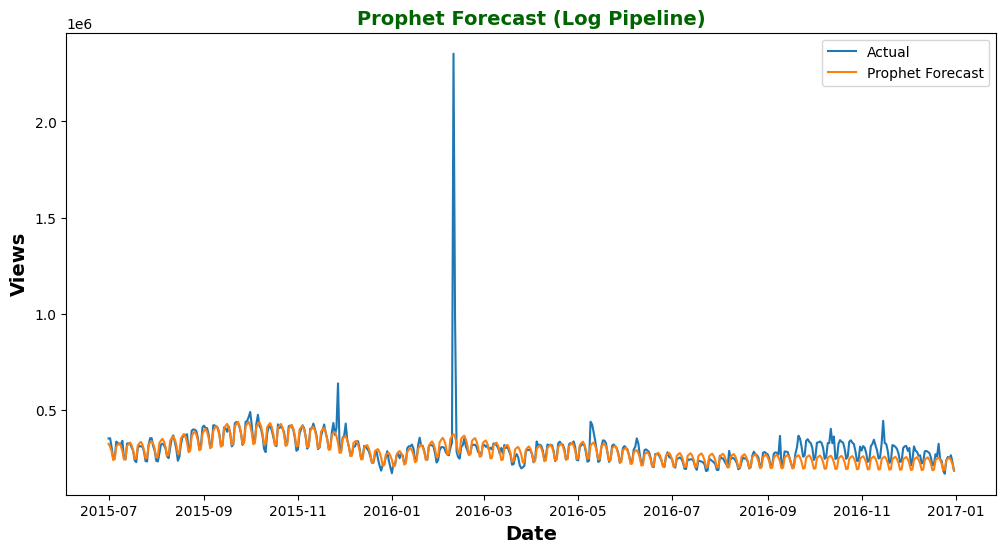

In [95]:
# Step 6: Plot
plt.figure(figsize = (12,6))

# Actual (converted back from log)
plt.plot(np.expm1(series_log), label = 'Actual')

# Forecast (converted back from log)
plt.plot(forecast_prophet['ds'], np.expm1(forecast_prophet['yhat']), label = 'Prophet Forecast')

plt.legend()
plt.title("Prophet Forecast (Log Pipeline)", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Date", fontsize = 14, fontweight = 'bold')
plt.ylabel("Views", fontsize = 14, fontweight = 'bold')
plt.show()

In [96]:
# Step 7: MAPE - Mean Absolute Percentage Error
print("Baseline Prophet MAPE:", mape(actual_values, forecast_values))

Baseline Prophet MAPE: 18.069676165718427


In [99]:
# Step 8: Perform Prophet hyperparameter tuning to identify the best model configuration based on lowest MAPE

models = [Prophet(weekly_seasonality = True),
          Prophet(changepoint_prior_scale = 0.05, weekly_seasonality = True),
          Prophet(changepoint_prior_scale = 0.5, weekly_seasonality = True),
          Prophet(seasonality_mode = 'multiplicative', weekly_seasonality = True),
          Prophet(changepoint_prior_scale = 0.5, seasonality_mode = 'multiplicative', weekly_seasonality = True)]

best_mape = float('inf')
best_model = None
best_model_name = None

for i, model in enumerate(models):
    model.fit(train_p)
    future = model.make_future_dataframe(periods = len(test_p))
    forecast = model.predict(future)
    pred_log = forecast['yhat'].iloc[train_size:].values
    pred = np.expm1(pred_log)
    score = mape(actual_values, pred)
    print(f"Model {i+1} MAPE:", score)

    if score < best_mape:
        best_mape = score
        best_model = model
        best_model_name = f"Model {i+1}"

print("\nBest Prophet Model:", best_model_name)
print("Best Prophet MAPE:", best_mape)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Model 1 MAPE: 18.069676165718427
Model 2 MAPE: 18.069676165718427


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Model 3 MAPE: 13.458541889232183
Model 4 MAPE: 17.81930221316496
Model 5 MAPE: 13.560111549709731

Best Prophet Model: Model 3
Best Prophet MAPE: 13.458541889232183


In [101]:
# STEP 9: Forecast with best model
future = best_model.make_future_dataframe(periods = len(test_p))
best_forecast = best_model.predict(future)

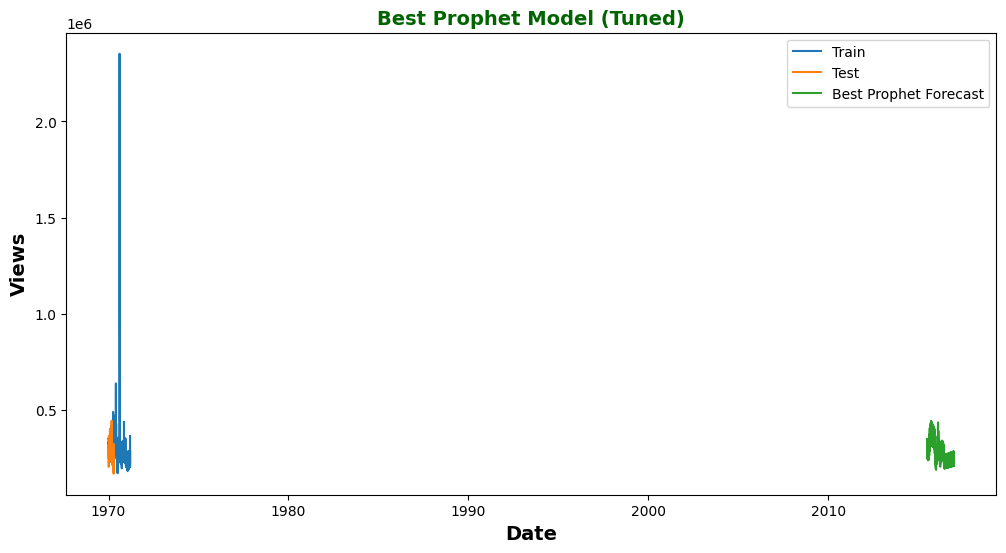

In [102]:
# Step 10: Plot
# Extract predictions
pred_log = best_forecast['yhat'].iloc[train_size:].values
pred = np.expm1(pred_log)

# Actual values
actual_values = np.expm1(test_p['y'].values)
train_actual = np.expm1(train_p['y'].values)

# Plot
plt.figure(figsize = (12,6))
plt.plot(train_actual, label = 'Train')
plt.plot(actual_values, label = 'Test')
plt.plot(best_forecast['ds'], np.expm1(best_forecast['yhat']), label = 'Best Prophet Forecast')
plt.legend()
plt.title("Best Prophet Model (Tuned)", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Date", fontsize = 14, fontweight = 'bold')
plt.ylabel("Views", fontsize = 14, fontweight = 'bold')
plt.show()

In [103]:
# STEP 11: MAPE - Mean Absolute Percentage Error
prophet_mape = mape(actual_values, pred)
print("\nFinal Prophet MAPE:", prophet_mape)


Final Prophet MAPE: 13.458541889232183


# **Time Series Forecasting Summary:**

**ARIMA → 1.23% (BEST)**

**SARIMAX → 11.72%**

**Prophet → 13.46%**

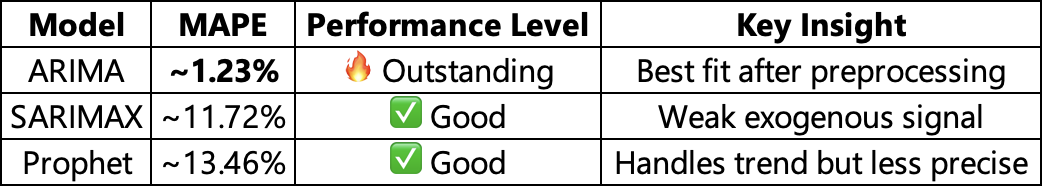

# **🔹 Why did ARIMA perform best? (Winner ✅)**

1. **Log transformation stabilized variance**
2. **Data became simple + structured**
3. **Weekly pattern captured**

**Because the data became well-structured after preprocessing, allowing ARIMA to capture patterns efficiently.**

#### **💡 Key insight:** **ARIMA works best when data is clean and well-behaved.**

# **🔹 Why didn't SARIMAX improve MAPE?**

**Campaign variable: Mostly zeros, Very few events, Weak relationship with views.**

**Because the exogenous variable was sparse and did not provide meaningful additional information.**

#### **💡 Key insight:** **SARIMAX does NOT automatically perform better than ARIMA. It only improves performance if the external variable (exog) adds useful information. SARIMAX only helps when exogenous variables are informative.**

# **🔹 Why didn't Prophet win?**

**1. Data became simple after preprocessing**

**2. No major nonlinear trends**

**3. No strong changepoints**

**Prophet is designed for complex trend changes, which were not present in this dataset.**

#### **💡 Key insight:** **Prophet shines when data has complex or changing trends, not when it's simple.**

# **Part F: Questionnaire**

**Q1: Defining the problem statements and where can this and modifications of this be used?**

- **The objective of this case study is to forecast daily Wikipedia page views for different pages and languages in order to optimize ad placement and predict user engagement.**
- **Accurate forecasting helps businesses allocate resources efficiently, improve targeting strategies, and maximize revenue from digital advertising.**

**It's applications are in:**

**1. E-commerce demand forecasting — predicting product demand to optimize inventory management.**

**2. Website traffic prediction — estimating future traffic for capacity planning and marketing campaigns.**

**3. Energy or stock forecasting — predicting consumption trends or market behavior for decision-making.**

**Q2: Write 3 inferences you made from the data visualizations**

- **The dataset exhibits a strong weekly seasonality pattern, where page views follow a consistent cycle across days of the week.**
- **The distribution of page views is highly skewed, with a small number of pages receiving very high traffic while most pages have relatively low views.**
- **There is significant variability and noise in the data, including sharp spikes, indicating the influence of external events or trending topics.**

**Q3: What does the decomposition of series do?**

**Time series decomposition breaks the data into three components:**

**Trend** → long-term movement of the series

**Seasonality** → repeating periodic patterns (e.g., weekly cycles)

**Residual** → random noise or unexplained variation

**This helps in understanding the underlying structure of the series and choosing appropriate modeling techniques.**

**Q4: What level of differencing gave you a stationary series?**

- **For the log-transformed series, first-order differencing (d = 1) was required to achieve stationarity, as confirmed by the ADF test.**
- **For the raw high-traffic series, the data was already stationary, so no differencing was required (d = 0).**

**This shows that transformation affects stationarity behavior.**

**Q5: Difference between arima, sarima & sarimax**

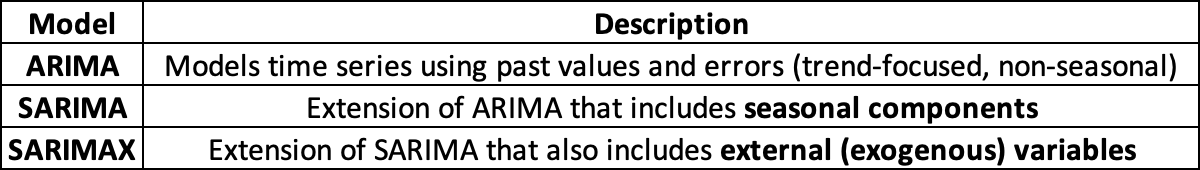

**ARIMA captures internal patterns, SARIMA adds seasonality, and SARIMAX incorporates external factors such as campaigns or events.**

**Compare the number of views in different languages**

- **English pages dominate the total number of views, contributing the highest traffic among all languages.**
- **Other major languages such as Japanese, German, and Spanish also show significant activity, while smaller language groups contribute comparatively less.**

**This highlights regional differences in user engagement and the importance of targeting high-traffic languages for advertisement optimization.**

**Q7: What other methods other than grid search would be suitable to get the model for all languages?**

- **Instead of grid search, the following methods can be used to scale modeling across multiple time series:**

1. **Auto-ARIMA** — automatically selects optimal (p, d, q) parameters using statistical criteria like AIC/BIC.
2. **Bayesian optimization** — efficiently searches parameter space using probabilistic models.
3. **Parallel processing / batching — runs models on multiple series simultaneously for scalability.**

**These methods reduce computational cost and are suitable for large datasets like the AdEase dataset used in this case study with thousands of time series.**

# **Part F: Insights and Recommendations**

# **Insights:**

**1. Data preprocessing had the biggest impact on performance. Applying log transformation significantly improved model performance, reducing ARIMA MAPE from ~16.5% to ~1.23%. This highlights the importance of handling variance and noise in time series data.**

**2. Simple models can outperform complex ones. ARIMA outperformed both SARIMAX and Prophet, showing that a well-tuned simple model can be more effective when the data exhibits stable and linear patterns.**

**3. Exogenous variables do not always improve predictions. SARIMAX performed worse than ARIMA because the campaign (exogenous) variable was sparse and did not provide meaningful predictive information.**

**4. Presence of strong weekly seasonality. The time series exhibited clear weekly patterns, which were captured effectively by ARIMA and Prophet, confirming the importance of seasonality in forecasting page views.**

# **Recommendations:**

**1. Use ARIMA as the primary forecasting model:**

**Since ARIMA achieved the lowest error (~1.23%), it should be used for predicting page views and optimizing ad placement.**

**2. Improve external data quality before using SARIMAX:**

**For SARIMAX to be effective, richer and more meaningful exogenous variables (e.g., events, promotions, holidays) should be incorporated.**

**3. Leverage language-based segmentation for marketing:**

**Different languages represent different user bases. High-traffic languages (like English and Chinese) should be prioritized for advertising and budget allocation.**

**4. Monitor spikes and unusual traffic patterns:**

**Sudden spikes in page views may indicate trending topics. Businesses should track these in real-time to capitalize on opportunities.**

**5. Use Prophet for more complex future scenarios:**

**While Prophet did not outperform ARIMA here, it can be useful for datasets with non-linear trends, multiple seasonality, or frequent structural changes.**

# **📄 Conclusion**

- **Three time series models — ARIMA, SARIMAX, and Prophet — were evaluated for forecasting Wikipedia page views.**
- **The ARIMA model, after log transformation and parameter tuning, achieved the best performance with a MAPE of approximately 1.23%. This indicates that the underlying data patterns were effectively captured using a relatively simple model.**

- **The SARIMAX model incorporated campaign data as an exogenous variable but did not outperform ARIMA, achieving a MAPE of around 11.72%. This was due to the sparse nature of the campaign data, which provided limited additional predictive value.**

- **Prophet, a flexible forecasting model, achieved a MAPE of approximately 13.46% after tuning. While it captured overall trends and seasonality, it did not outperform ARIMA, as the dataset did not exhibit complex nonlinear patterns.**

**Overall, the case study demonstrates that proper data preprocessing and model selection are crucial for accurate forecasting. Simpler models like ARIMA can outperform more complex approaches when the data is well-structured, reinforcing the importance of understanding data characteristics before choosing advanced techniques.**